# Clase 4 — Mecanismo de atención (conceptual)

**Módulo de Análisis de Datos de Texto · Notebook 4 de 5**

Los embeddings de la clase 3 son **estáticos**: cada palabra tiene un único vector. Hoy implementaremos, *en miniatura*, el mecanismo de **atención** que permite que la representación de una palabra cambie según las otras palabras de la frase.

> Este notebook es **demostrativo**. No vamos a entrenar nada: vamos a implementar la atención en NumPy sobre vectores de juguete para ver cómo funciona la operación de **comparar → ponderar → combinar**.

## 1. Vectores de juguete

Supongamos que tenemos 4 palabras representadas por vectores de 3 dimensiones. (En un modelo real serían cientos de dimensiones y vendrían de la capa de embeddings, pero la operación es exactamente la misma.)

In [1]:
import numpy as np
np.random.seed(0)

#pregutna de manuel ¿si son 4 palabras por qué representadas 
# en vector de 3 dimensiones?

palabras = ["el", "banco", "del", "parque"]

#supongamos que ya se crearon los embeddings y cada palabra
# tiene su respectivo vector. Ahora entonces verémos como pasamos
# de un vector incial a un vector contextual por medio del mecanismo de 
# atención. 
# Embeddings inventados (3 dimensiones)
E = np.array([
    [0.1, 0.2, 0.0],     # el
    [0.6, 0.1, 0.3],     # banco
    [0.1, 0.2, 0.0],     # del
    [0.0, 0.5, 0.8],     # parque
])
print("Embeddings de entrada (4 palabras x 3 dims):")
print(E)

Embeddings de entrada (4 palabras x 3 dims):
[[0.1 0.2 0. ]
 [0.6 0.1 0.3]
 [0.1 0.2 0. ]
 [0.  0.5 0.8]]


## 2. Paso 1 — Comparar

Cada palabra mide cuánto se relaciona con cada otra, mediante un **producto punto** (la misma idea de similitud que vimos en la clase 2). El resultado es una matriz de **scores** de tamaño 4×4 (cada palabra contra cada palabra).

In [ ]:
scores = E @ E.T          # producto punto entre todos los pares
print("Matriz de scores (sin normalizar):")
print(np.round(scores, 3))

#cada palabra se compara con cada una de las palabras de la frase. 
#y se hace mediante el producto punto pues se relaziona con el coseno. 

#¿Por qué producto punto?

Matriz de scores (sin normalizar):
[[0.05 0.08 0.05 0.1 ]
 [0.08 0.46 0.08 0.29]
 [0.05 0.08 0.05 0.1 ]
 [0.1  0.29 0.1  0.89]]


El producto punto se utiliza en los mecanismos de atención porque es la forma matemática más rápida y natural de responder a la pregunta: ¿qué tanto se alinean o se relacionan dos vectores?

En el modelo de atención (como en la arquitectura Transformer), cada palabra emite una Query (pregunta: "¿qué estoy buscando?") y las demás palabras responden con una Key (clave: "esto es lo que ofrezco"). El producto punto entre la Query y la Key calcula qué tan buena es esa coincidencia.

![producto_punto](../imagenes/dot_product.png)

1. Mide la "similitud" u orientación entre vectoresGeométricamente, el producto punto entre dos vectores $\mathbf{a}$ y $\mathbf{b}$ se define como:$$\mathbf{a} \cdot \mathbf{b} = \Vert{}\mathbf{a}\Vert{} \Vert{}\mathbf{b}\Vert{} \cos(\theta)$$

Si dos vectores apuntan en la misma dirección ($\theta = 0^\circ$): el coseno es $1$, dando el resultado más positivo posible. Significa que ambos vectores comparten muchas características conceptuales.

Si son perpendiculares ($\theta = 90^\circ$): el coseno es $0$. No tienen ninguna relación conceptual.Si apuntan en direcciones opuestas ($\theta = 180^\circ$): el resultado es negativo. Tienen significados opuestos.

En tu ejemplo de "el banco del parque", cuando el vector Query de la palabra "banco" se multiplica escalarmente por el vector Key de "parque", como ambas palabras comparten un contexto geográfico/espacial en sus valores numéricos, el producto punto da un resultado elevado.

2. Es extremadamente eficiente para las computadoras
Desde el punto de vista computacional, el producto punto de dos vectores consiste simplemente en:

Multiplicar elemento por elemento.

Sumar todos los resultados.

Esto se traduce en multiplicación de matrices masiva. Las tarjetas gráficas (GPUs) y unidades de procesamiento (TPUs) están optimizadas a nivel de hardware para ejecutar multiplicaciones de matrices a velocidades altísimas. Otras formas de comparar vectores (como la distancia euclidiana) requieren operaciones más lentas como calcular diferencias y raíces cuadradas.

3. Es diferenciable para el aprendizaje
El producto punto es una función matemática suave cuyas derivadas son muy sencillas. Esto permite que el algoritmo de aprendizaje (Backpropagation) ajuste los pesos de la red neuronal de forma eficiente durante el entrenamiento.

## 3. Paso 2 — Ponderar (softmax)

Convertimos los scores en **pesos** que sumen 1 (por fila). Eso es lo que hace la función *softmax*.

In [ ]:
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

pesos = softmax(scores, axis=1)
print("Pesos de atención (cada fila suma 1):")
print(np.round(pesos, 3))
print("\nSuma por fila:", pesos.sum(axis=1))

#recordemos la matriz representa las palabras como
#       el    banco   del     parque
# el
# banco
# del
# parque

Pesos de atención (cada fila suma 1):
[[0.245 0.252 0.245 0.258]
 [0.213 0.311 0.213 0.263]
 [0.245 0.252 0.245 0.258]
 [0.185 0.223 0.185 0.407]]

Suma por fila: [1. 1. 1. 1.]


Entonces por ejemplo el mecanismo de atención  para la palabra "banco" las palabras con más peso son "banco" y "parque".

Cada fila es una distribución de atención y su peso muestra la representación de la palabra para su contextualización 

## 4. Paso 3 — Combinar

Cada palabra se convierte en un **promedio ponderado** de todas las palabras de la frase, usando los pesos de atención. Esa es su nueva representación, *contextual*.

In [4]:
salida = pesos @ E
print("Embeddings contextuales (4 x 3):")
print(np.round(salida, 3))

Embeddings contextuales (4 x 3):
[[0.2   0.252 0.282]
 [0.229 0.248 0.304]
 [0.2   0.252 0.282]
 [0.171 0.3   0.393]]


volvemos a estas dimensiones porque cada palabra estaba representada en un vector de 3 dimensiones. 

## 5. Visualizar los pesos: ¿quién mira a quién?

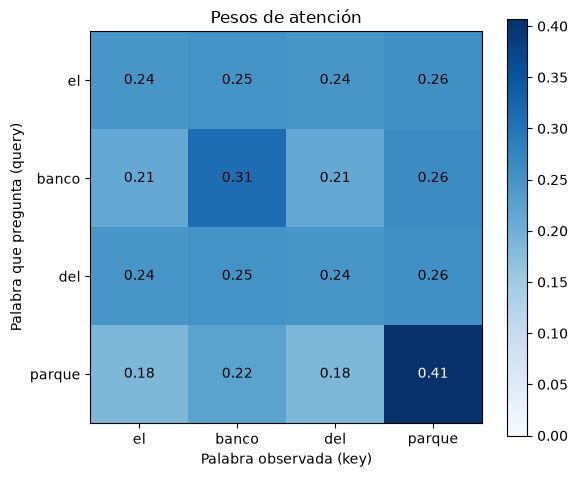

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pesos, cmap="Blues", vmin=0, vmax=pesos.max())
ax.set_xticks(range(len(palabras))); ax.set_xticklabels(palabras)
ax.set_yticks(range(len(palabras))); ax.set_yticklabels(palabras)
ax.set_xlabel("Palabra observada (key)")
ax.set_ylabel("Palabra que pregunta (query)")
ax.set_title("Pesos de atención")

# Anotar valores en cada celda
for i in range(len(palabras)):
    for j in range(len(palabras)):
        ax.text(j, i, f"{pesos[i,j]:.2f}",
                ha="center", va="center",
                color="white" if pesos[i,j] > 0.4 else "black", fontsize=10)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

## 6. Cambiar el contexto: misma palabra, distinta representación

Ahora cambiamos la frase a *"el banco del país"* — la misma palabra `"banco"` rodeada de otro contexto. Veamos cómo cambia su representación de salida.

In [6]:
palabras_v2 = ["el", "banco", "del", "país"]
E2 = np.array([
    [0.1, 0.2, 0.0],     # el       (igual)
    [0.6, 0.1, 0.3],     # banco    (igual)
    [0.1, 0.2, 0.0],     # del      (igual)
    [0.7, 0.0, 0.2],     # país     (DIFERENTE)
])

scores2 = E2 @ E2.T
pesos2  = softmax(scores2, axis=1)
salida2 = pesos2 @ E2

# Comparar la fila de "banco" en ambas frases
idx_banco = 1
print("Embedding contextual de 'banco':")
print(f"  Frase 1 ('el banco del parque'): {salida [idx_banco].round(3)}")
print(f"  Frase 2 ('el banco del país'):   {salida2[idx_banco].round(3)}")
print(f"\nDiferencia (norma): {np.linalg.norm(salida[idx_banco] - salida2[idx_banco]):.3f}")

Embedding contextual de 'banco':
  Frase 1 ('el banco del parque'): [0.229 0.248 0.304]
  Frase 2 ('el banco del país'):   [0.428 0.11  0.149]

Diferencia (norma): 0.287


**La misma palabra `"banco"`, distinta representación.** Eso es lo que los embeddings estáticos *no* podían hacer y los Transformers sí. La idea de fondo es exactamente la que acabamos de programar: comparar, ponderar, combinar.

## 7. Lo que dejamos fuera (para que sepas qué hay debajo)

Lo que implementamos es self-attention en su forma más simple. Un Transformer real agrega varias cosas que no son conceptualmente distintas, solo más sofisticadas:

- **Q, K, V**: en vez de usar `E` directamente para los tres roles, proyecta `E` por tres matrices distintas que el modelo aprende.
- **Escalado**: divide los scores por `sqrt(d)` para que el softmax no se sature.
- **Cabezas múltiples** (*multi-head*): repite la operación varias veces en paralelo con distintas proyecciones, para capturar diferentes tipos de relación.
- **Codificación posicional**: agrega información sobre el orden de las palabras (porque la atención por sí sola no sabe quién vino antes).

Nada de esto cambia la intuición de tres pasos: **comparar, ponderar, combinar**.

## 8. Ejercicios

In [ ]:
# Ejercicio 1: implementa una función atencion(E) que reciba una matriz de
# embeddings y devuelva (pesos, salida). Aplícala a una frase de tu elección
# y muestra el heatmap de pesos.

# TODO:


In [ ]:
# Ejercicio 2: agrega el escalado por sqrt(d) a tus scores antes del softmax.
# d es la dimensión de los vectores. Compara los pesos con y sin escalado.

# TODO:


In [ ]:
# Ejercicio 3 (reflexión): ¿por qué la diagonal de la matriz de pesos suele
# tener valores altos? ¿Qué significa eso intuitivamente?

# TODO:


## Lo que sigue

Ya tenemos representaciones que dependen del contexto. Si en lugar de solo *entender* le pedimos al modelo que **prediga la siguiente palabra**, obtenemos un generador.

**Próxima clase:** modelos de lenguaje e IA generativa.